# Sub-ICB Paracetamol Prescribing Analysis
### Exploring Liquid vs Non-Liquid Paracetamol Prescribing Patterns Across NHS Sub-ICBs
---
**Data source:** Sub ICB Metric Data — NHS prescribing data across 106 Sub-Integrated Care Boards (Sub-ICBs) in England 
( link:https://nhsbsa-data-analytics.github.io/liquid-paracetamol-prescribing-care-homes/#liquid-paracetamol-prescribing-costs-for-care-homes-patients-have-increased ) 
**Period covered:** 2020/21 to 2024/25  
**Prepared using:** Python (pandas, matplotlib, seaborn)

---
## About This Analysis

Liquid paracetamol is the clinically appropriate choice for patients who cannot safely swallow solid tablets. This is a common and legitimate clinical need — particularly among care home residents, people with dysphagia, those living with advanced dementia, or patients receiving care via nasogastric or PEG tubes. For these patients, liquid formulations are not a preference but a necessity.

However, liquid formulations are substantially more expensive per dose than their tablet equivalents, which raises important questions about clinical appropriateness and prescribing efficiency across NHS areas. This dataset allows us to explore how liquid prescribing volumes and costs have changed over time nationally, and how prescribing patterns vary across Sub-Integrated Care Boards (Sub-ICBs) in England.

This notebook explores:
- How liquid paracetamol prescribing has changed over time nationally
- How costs have evolved, including a sharp cost-per-item increase from 2021/22 onwards
- How much variation exists across Sub-ICBs in the proportion of liquid prescribing
- Which areas have the highest absolute costs and whether high-volume areas also tend to prescribe more liquid proportionally

Important framing: Variation in liquid prescribing rates across Sub-ICBs does not straightforwardly indicate good or poor practice. Higher rates may reflect a Sub-ICB with a larger care home population, higher rates of dysphagia, or older and more complex patients. Lower rates may reflect the same in reverse. This analysis describes patterns in the data; it does not make judgements about clinical appropriateness, which would require patient-level data beyond the scope of this dataset.

The rising costs observed are largely attributable to national supply chain and manufacturer price increases — factors outside individual Sub-ICB control.


---
## 1. Setup and Data Loading

Started by importing the required libraries and loading the dataset. Also applied a consistent colour palette inspired by NHS identity guidelines throughout.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NHS-inspired colour palette 

NHS_BLUE    = '#005EB8'
NHS_DARK    = '#003087'
NHS_PINK    = '#AE2573'
NHS_TEAL    = '#009999'
NHS_GREEN   = '#009639'
NHS_ORANGE  = '#ED8B00'
NHS_GREY    = '#768692'
NHS_LIGHT   = '#E8EDEE'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E5E5E5',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})

# Load data 
df = pd.read_csv('Sub ICB Metric Data.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Financial years: {sorted(df['Financial year'].unique())}")
print(f"Paracetamol types: {df['Paracetamol type'].unique().tolist()}")
print(f"Sub-ICBs: {df['Sub ICB'].nunique()}")


Dataset shape: 1,060 rows × 12 columns
Financial years: ['2020/21', '2021/22', '2022/23', '2023/24', '2024/25']
Paracetamol types: ['Liquid', 'Non-liquid']
Sub-ICBs: 106



## 2. Data Overview

Before any analysis, the structure of the data was inspected to understand what each column represents and confirm there are no missing values.


In [ ]:
df.head(6) # displays first 6 rows


In [ ]:
print("Column data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())


**What each column means:**

| Column | Description |
|---|---|
| `Financial year` | NHS financial year (April–March) |
| `Sub ICB` | Sub-Integrated Care Board — a geographic NHS commissioning unit |
| `Paracetamol type` | Either `Liquid` or `Non-liquid` |
| `Item count` | Number of prescription items of this type in this Sub-ICB |
| `Total item count` | Total paracetamol items (liquid + non-liquid) in this Sub-ICB |
| `Cost` | Net ingredient cost (£) for this paracetamol type |
| `Total cost` | Total paracetamol cost across both types |
| `Patient count` | Unique patients receiving this paracetamol type |
| `Total patients` | Unique patients receiving any paracetamol |
| `Percentage of items` | `Item count / Total item count × 100` |
| `Percentage of cost` | `Cost / Total cost × 100` |
| `Percentage of patients` | `Patient count / Total patients × 100` |

The dataset is clean with **no missing values**. Each Sub-ICB appears twice per year, once for liquid and once for non-liquid prescribing.


**A note on what this data cannot tell us:** This is an aggregate dataset at Sub-ICB level. It does not contain individual patient records, diagnoses, care home registrations, or clinical indications. Any observations about rates or costs therefore describe population-level patterns only, and should not be interpreted as evidence of over- or under-prescribing without additional clinical context.


---
## 3. National Trends in Liquid Paracetamol Prescribing

We begin by aggregating to national level to understand how the overall scale of liquid paracetamol prescribing has changed across all Sub-ICBs combined.


In [4]:
nat_all = (df.groupby(['Financial year', 'Paracetamol type'])
             .agg(items=('Item count', 'sum'),
                  cost=('Cost', 'sum'),
                  patients=('Patient count', 'sum'))
             .reset_index())

liquid_nat = nat_all[nat_all['Paracetamol type'] == 'Liquid'].copy()
liquid_nat['cost_per_item']    = liquid_nat['cost'] / liquid_nat['items']
liquid_nat['cost_per_patient'] = liquid_nat['cost'] / liquid_nat['patients']

display_df = liquid_nat[['Financial year','items','cost','patients','cost_per_item','cost_per_patient']].copy()
display_df.columns = ['Year','Items','Cost (£)','Patients','Cost per item (£)','Cost per patient (£)']
display_df = display_df.set_index('Year')
display_df.style.format({'Items':'{:,.0f}','Cost (£)':'{:,.0f}',
                          'Patients':'{:,.0f}','Cost per item (£)':'{:.2f}',
                          'Cost per patient (£)':'{:.2f}'})


,Items,Cost (£),Patients,Cost per item (£),Cost per patient (£)
Year,,,,,
2020/21,"271,790","4,728,060","68,150",17.40,69.38
2021/22,"282,470","4,863,350","66,280",17.22,73.38
2022/23,"303,860","9,323,790","72,460",30.68,128.67
2023/24,"330,620","11,293,190","76,020",34.16,148.56
2024/25,"371,130","16,056,910","83,010",43.26,193.43


### 3.1 Total Items, Cost, and Patients Over Time

The charts below show how the total volume of liquid paracetamol prescriptions, the total cost incurred, and the number of patients receiving liquid paracetamol have all changed year on year.

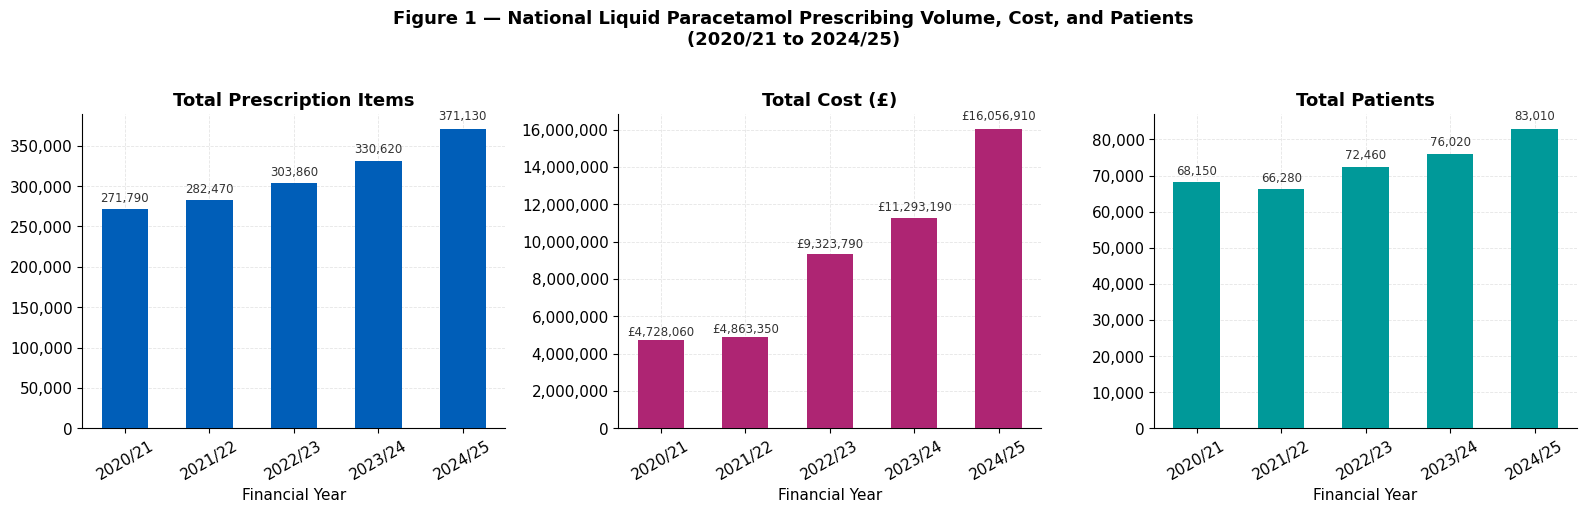

In [5]:
years = liquid_nat['Financial year'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('items',    'Total Prescription Items',  NHS_BLUE,  '{:,.0f}'),
    ('cost',     'Total Cost (£)',             NHS_PINK,  '£{:,.0f}'),
    ('patients', 'Total Patients',             NHS_TEAL,  '{:,.0f}'),
]

for ax, (col, title, colour, fmt) in zip(axes, metrics):
    vals = liquid_nat[col].values
    bars = ax.bar(years, vals, color=colour, width=0.55, zorder=3)
    ax.set_title(title)
    ax.set_xlabel('Financial Year')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt.format(v), ha='center', va='bottom', fontsize=8.5, color='#333')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt.format(x)))

fig.suptitle('Figure 1 — National Liquid Paracetamol Prescribing Volume, Cost, and Patients\n(2020/21 to 2024/25)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig1_national_volume_cost_patients.png', dpi=150, bbox_inches='tight')
plt.show()


**What this tells us:**

Across all three measures: items, cost, and patients - liquid paracetamol prescribing has grown consistently every year between 2020/21 and 2024/25:

- **Items** increased from approximately 272,000 in 2020/21 to 371,000 in 2024/25, a rise of around **37%** over five years.  This suggests a genuine growth in the patient population requiring liquid formulations, consistent with an ageing population and increasing care home capacity.
- **Cost** rose far more sharply — from £4.7 million to £16.1 million, an increase of **240%**. This is substantially higher than the growth in item volumes, indicating that the cost per item has itself risen steeply (explored further in Section 3.2).
- **Patients** receiving liquid paracetamol grew from around 68,000 to 83,000, an increase of **22%** broadly in line with national trends in care home population growth.

The divergence between volume growth (~37%) and cost growth (~240%) is the most striking finding at the national level. It indicates that the majority of the cost increase is driven by rising unit prices, not by more patients receiving liquid paracetamol. This points to supply-side and procurement issue, not to primarily a prescribing behaviour.



### 3.2 Cost Per Item and Cost Per Patient


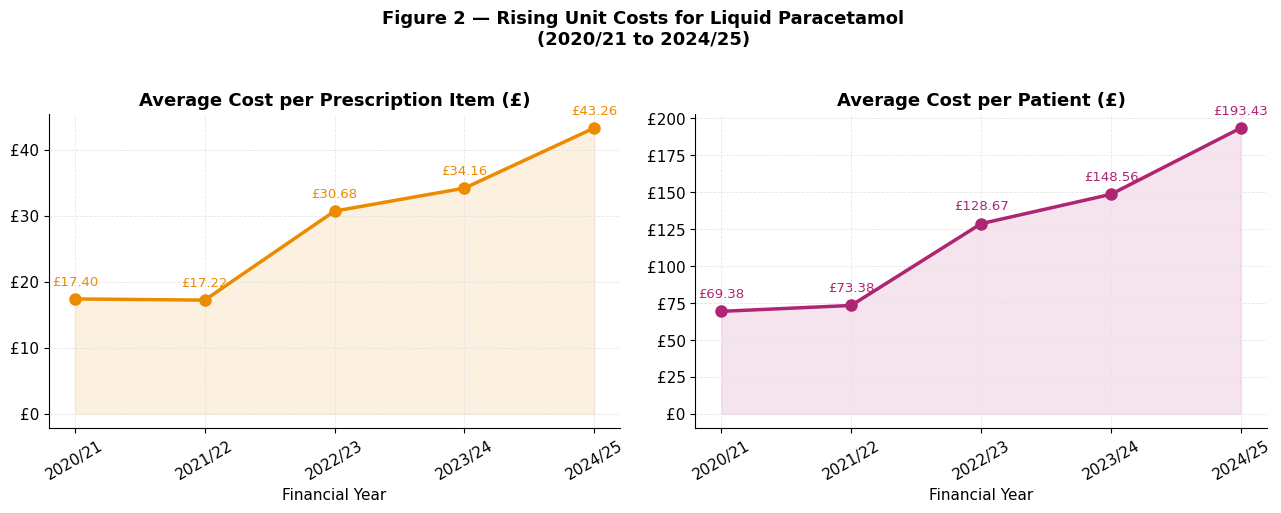

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, colour, fmt in [
    (axes[0], 'cost_per_item',    'Average Cost per Prescription Item (£)', NHS_ORANGE, '£{:.2f}'),
    (axes[1], 'cost_per_patient', 'Average Cost per Patient (£)',           NHS_PINK,   '£{:.2f}'),
]:
    vals = liquid_nat[col].values
    ax.plot(years, vals, marker='o', linewidth=2.5, markersize=8, color=colour, zorder=3)
    ax.fill_between(years, vals, alpha=0.12, color=colour)
    for x, y in zip(years, vals):
        ax.annotate(fmt.format(y), (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9.5, color=colour)
    ax.set_title(title)
    ax.set_xlabel('Financial Year')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '£{:.0f}'.format(x)))

fig.suptitle('Figure 2 — Rising Unit Costs for Liquid Paracetamol\n(2020/21 to 2024/25)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig2_unit_costs.png', dpi=150, bbox_inches='tight')
plt.show()


**What this tells us:**

The cost per prescription item for liquid paracetamol rose from £17.40 in 2020/21 to £43.26 in 2024/25 — a **149% increase** over five years. The sharpest jump occurred between 2021/22 and 2022/23, when the cost per item nearly doubled from £17.22 to £30.68.

This pattern is consistent with broader NHS reporting on supply chain disruption and manufacturer price increases affecting liquid medicine formulations, which are inherently more complex and costly to produce than solid-dose tablets. These price increases are a national and international supply-side issue and are not driven by individual prescribing decisions at Sub-ICB or practice level.

Cost per patient followed the same trajectory, **rising from £69 to £193** which indicates the NHS now spends nearly three times as much per liquid paracetamol patient as it did in 2020/21, for the same clinical outcome.


## 4. Liquid vs Non-Liquid: Share of Items, Cost, and Patients

Liquid paracetamol accounts for a minority of all paracetamol prescriptions, but its share of total cost is disproportionately high due to the premium unit price. This section shows how those shares have shifted over time.


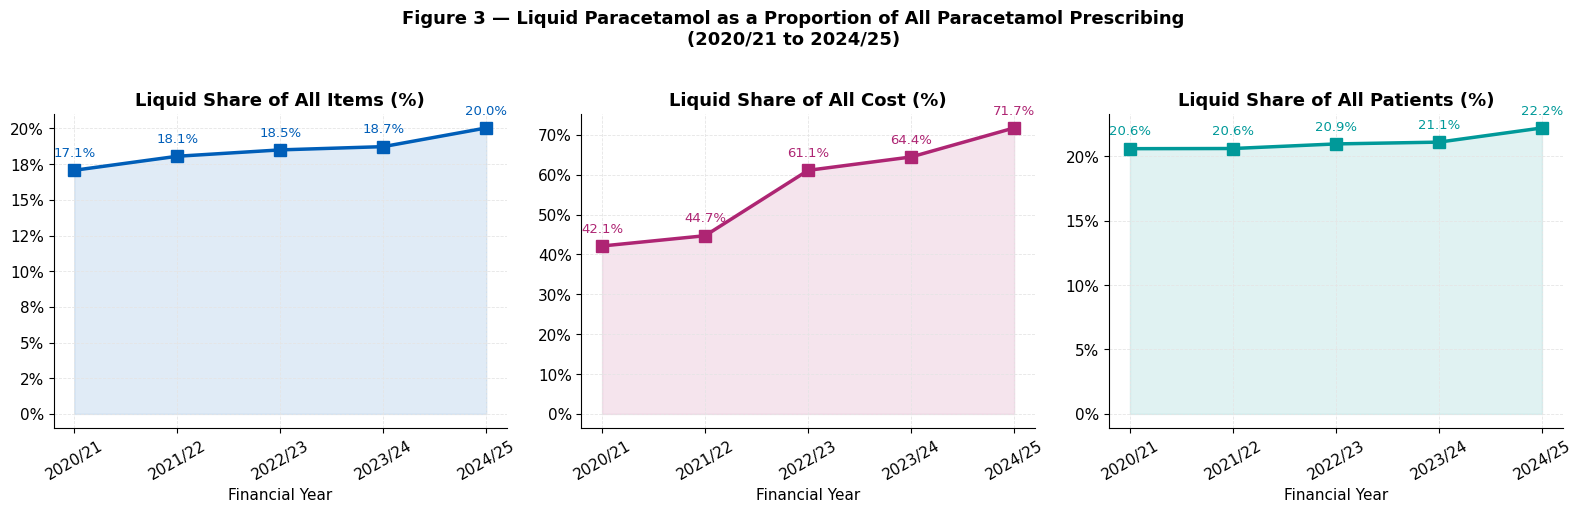

In [7]:
pivot = (nat_all.pivot_table(index='Financial year', columns='Paracetamol type',
                              values=['items','cost','patients'], aggfunc='sum'))
pivot.columns = ['_'.join(c) for c in pivot.columns]
pivot = pivot.reset_index()

pivot['pct_items']    = pivot['items_Liquid']    / (pivot['items_Liquid']    + pivot['items_Non-liquid'])    * 100
pivot['pct_cost']     = pivot['cost_Liquid']     / (pivot['cost_Liquid']     + pivot['cost_Non-liquid'])     * 100
pivot['pct_patients'] = pivot['patients_Liquid'] / (pivot['patients_Liquid'] + pivot['patients_Non-liquid']) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colours = [NHS_BLUE, NHS_PINK, NHS_TEAL]
titles = ['Liquid Share of All Items (%)', 'Liquid Share of All Cost (%)', 'Liquid Share of All Patients (%)']
cols   = ['pct_items', 'pct_cost', 'pct_patients']

for ax, col, title, colour in zip(axes, cols, titles, colours):
    vals = pivot[col].values
    ax.plot(years, vals, marker='s', linewidth=2.5, markersize=8, color=colour, zorder=3)
    ax.fill_between(years, vals, alpha=0.12, color=colour)
    for x, y in zip(years, vals):
        ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9.5, color=colour)
    ax.set_title(title)
    ax.set_xlabel('Financial Year')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

fig.suptitle('Figure 3 — Liquid Paracetamol as a Proportion of All Paracetamol Prescribing\n(2020/21 to 2024/25)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig3_liquid_share_proportions.png', dpi=150, bbox_inches='tight')
plt.show()


**What this tells us:**

Despite liquid paracetamol representing only around **17–20% of all prescription items**, its share of total paracetamol **cost has now exceeded 70%** (rising from 42% in 2020/21 to over 71% in 2024/25). This is a profound cost-efficiency signal: a small proportion of prescriptions is consuming the majority of the paracetamol prescribing budget.

The share of patients receiving liquid formulations has remained relatively stable at around 20%, suggesting the patient population driving these prescriptions has not grown dramatically — rather, unit price increases are the primary driver of the rising cost share.

This disparity between volume share and cost share is a key concern for NHS commissioners and is consistent with NHSBSA findings about liquid paracetamol prescribing in care home settings.



### 4.1 Stacked Cost Comparison: Liquid vs Non-Liquid


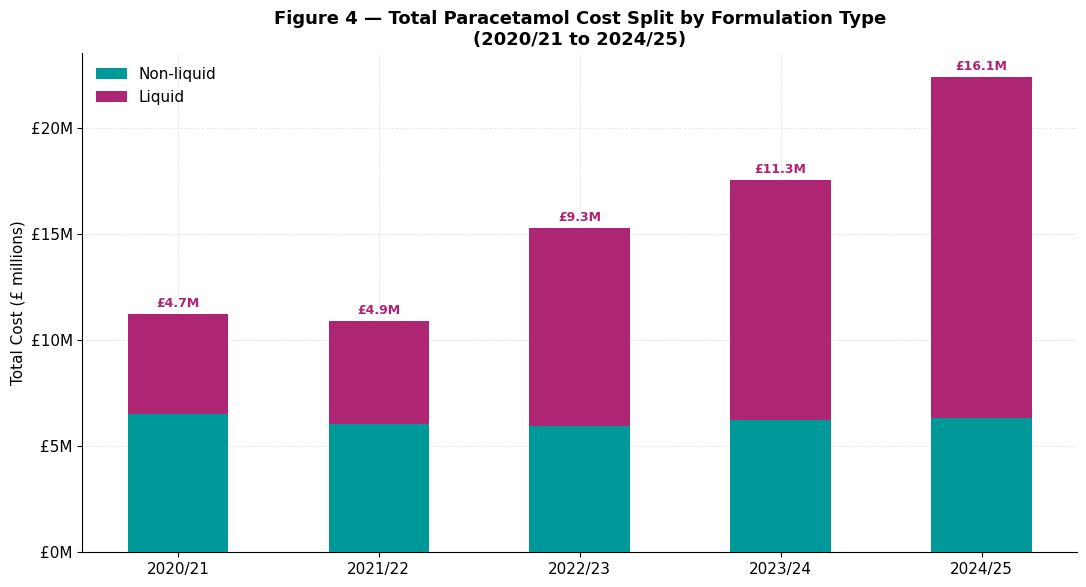

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

liquid_costs    = pivot['cost_Liquid'].values / 1e6
nonliquid_costs = pivot['cost_Non-liquid'].values / 1e6
x = np.arange(len(years))
width = 0.5

p1 = ax.bar(x, nonliquid_costs, width, label='Non-liquid', color=NHS_TEAL,  zorder=3)
p2 = ax.bar(x, liquid_costs,    width, label='Liquid',     color=NHS_PINK,  zorder=3,
            bottom=nonliquid_costs)

for i, (lc, nlc) in enumerate(zip(liquid_costs, nonliquid_costs)):
    ax.text(i, nlc + lc + 0.2, f'£{lc:.1f}M', ha='center', va='bottom',
            fontsize=9, color=NHS_PINK, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Total Cost (£ millions)')
ax.set_title('Figure 4 — Total Paracetamol Cost Split by Formulation Type\n(2020/21 to 2024/25)',
             fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}M'))
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig4_stacked_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:**

In 2020/21, liquid and non-liquid paracetamol cost broadly similar amounts nationally (£4.7M vs £6.5M). By 2024/25, liquid costs had reached £16.1 million while non-liquid costs remained flat at around £6.3 million.

Non-liquid costs have actually been stable or slightly declining in real terms which is a sign that tablet prescribing is relatively well-controlled and that supply prices for that formulation have not changed significantly. The overall growth in paracetamol expenditure is therefore almost entirely attributable to the rising price of liquid formulations.


## 5. Geographic Variation Across Sub-ICBs

With 106 Sub-ICBs in the dataset, we can examine how liquid prescribing rates vary geographically. It is important to interpret this variation carefully.

**What variation in this metric can and cannot tell us:**
- A higher rate of liquid prescribing may reflect a Sub-ICB with more care home beds, more complex patients, higher dysphagia prevalence, or a more thorough assessment process that correctly identifies patients who need liquid formulations.
- A lower rate may equally reflect a younger or less complex population, fewer care home places, or in some cases patients who might benefit from liquid formulations not receiving them.
- Neither a high nor a low rate is inherently problematic without understanding the underlying patient population. This data alone cannot determine clinical appropriateness.


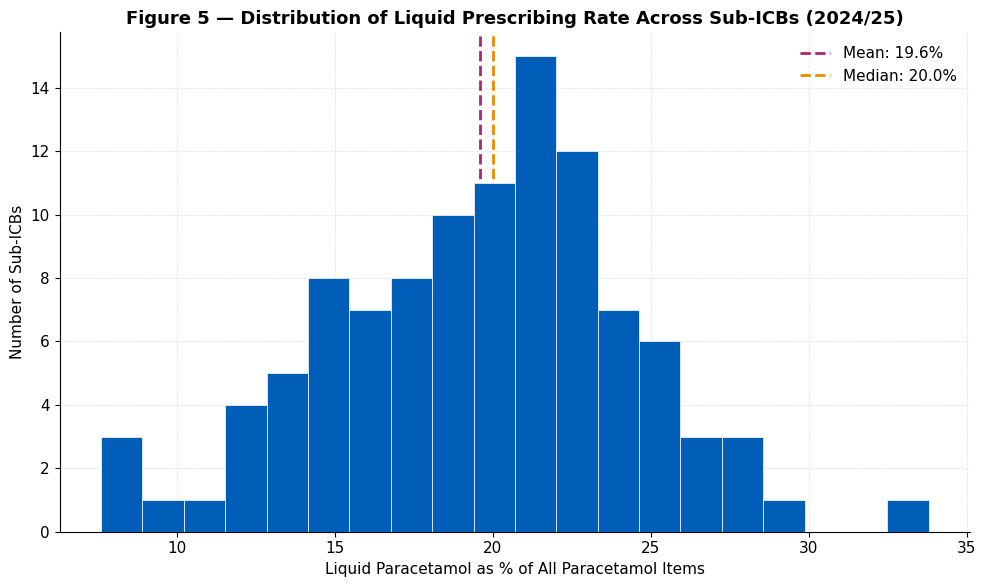

Range: 7.6% – 33.8%
IQR: 16.1% – 22.8%


In [9]:
liquid = df[df['Paracetamol type'] == 'Liquid'].copy()
latest = liquid[liquid['Financial year'] == '2024/25'].copy()
latest['sub_short'] = latest['Sub ICB'].str.split(' - ').str[0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(latest['Percentage of items'], bins=20, color=NHS_BLUE, edgecolor='white', linewidth=0.5, zorder=3)
ax.axvline(latest['Percentage of items'].mean(), color=NHS_PINK, linewidth=2,
           linestyle='--', label=f"Mean: {latest['Percentage of items'].mean():.1f}%")
ax.axvline(latest['Percentage of items'].median(), color=NHS_ORANGE, linewidth=2,
           linestyle='--', label=f"Median: {latest['Percentage of items'].median():.1f}%")
ax.set_xlabel('Liquid Paracetamol as % of All Paracetamol Items')
ax.set_ylabel('Number of Sub-ICBs')
ax.set_title('Figure 5 — Distribution of Liquid Prescribing Rate Across Sub-ICBs (2024/25)',
             fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig5_distribution_liquid_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Range: {latest['Percentage of items'].min():.1f}% – {latest['Percentage of items'].max():.1f}%")
print(f"IQR: {latest['Percentage of items'].quantile(0.25):.1f}% – {latest['Percentage of items'].quantile(0.75):.1f}%")


**What this shows:**

In 2024/25, the proportion of paracetamol prescriptions that are liquid ranges from 7.6% to 33.8% across Sub-ICBs — a **more than fourfold difference** between the lowest and highest areas.

The distribution is roughly bell-shaped, centred around 20%. The spread of an interquartile range of roughly 16% to 23% is moderate but not extreme for a population-level prescribing metric. Most Sub-ICBs cluster within a relatively narrow band, with a smaller number of outliers at either end.

This variation is worth monitoring but should raise **questions rather than conclusions**. Understanding whether outlier Sub-ICBs have distinctive patient populations, care home densities, or formulary practices would be the appropriate next step before drawing any inferences about prescribing quality.


### 5.1 Highest and Lowest Sub-ICBs by Liquid Prescribing Rate (2024/25)


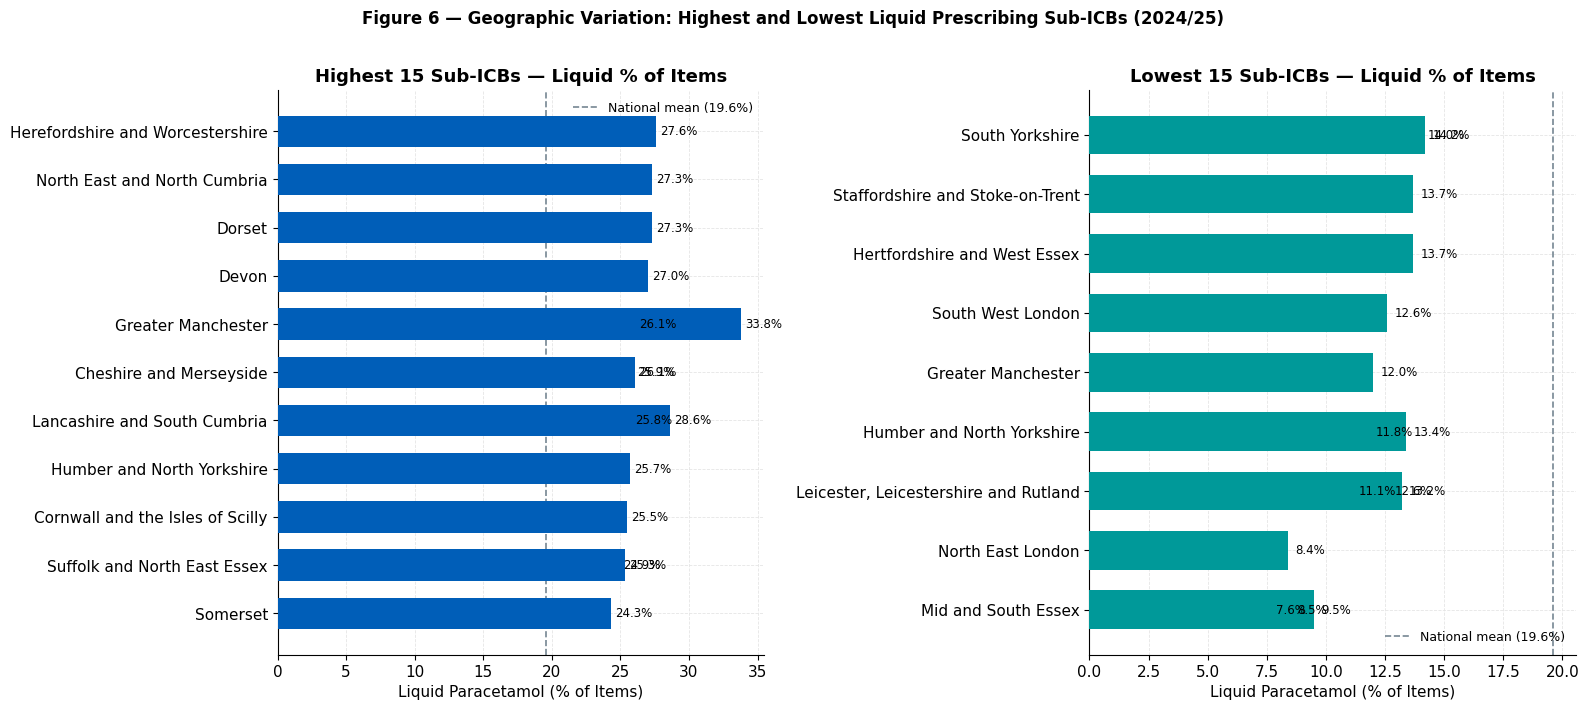

In [10]:
top15    = latest.nlargest(15,  'Percentage of items')
bottom15 = latest.nsmallest(15, 'Percentage of items')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, colour, label in [
    (axes[0], top15,    NHS_BLUE, 'Highest 15 Sub-ICBs — Liquid % of Items'),
    (axes[1], bottom15, NHS_TEAL, 'Lowest 15 Sub-ICBs — Liquid % of Items'),
]:
    data_sorted = data.sort_values('Percentage of items', ascending=True)
    bars = ax.barh(data_sorted['sub_short'], data_sorted['Percentage of items'],
                   color=colour, height=0.65, zorder=3)
    for bar, v in zip(bars, data_sorted['Percentage of items']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8.5)
    ax.set_xlabel('Liquid Paracetamol (% of Items)')
    ax.set_title(label, fontweight='bold')
    ax.axvline(latest['Percentage of items'].mean(), color=NHS_GREY, linewidth=1.2,
               linestyle='--', label=f'National mean ({latest["Percentage of items"].mean():.1f}%)')
    ax.legend(frameon=False, fontsize=9)

fig.suptitle('Figure 6 — Geographic Variation: Highest and Lowest Liquid Prescribing Sub-ICBs (2024/25)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig6_highest_lowest_subicbs.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:**

Greater Manchester leads with **33.8%** of all paracetamol items being liquid which is more than **four times higher** than Mid and South Essex (7.6%). Lancashire and South Cumbria, Herefordshire and Worcestershire, and Dorset also appear consistently in the high end.

The causes of this variation are multifactorial and may reflect differences in the age structure of care home populations, local formulary decisions, GP prescribing culture, or the proportion of patients with dysphagia or complex needs. Understanding **why** some areas prescribe liquid formulations at much higher rates is the next step for commissioners.


### 5.2 Sub-ICBs by Total Liquid Paracetamol Cost (2024/25)


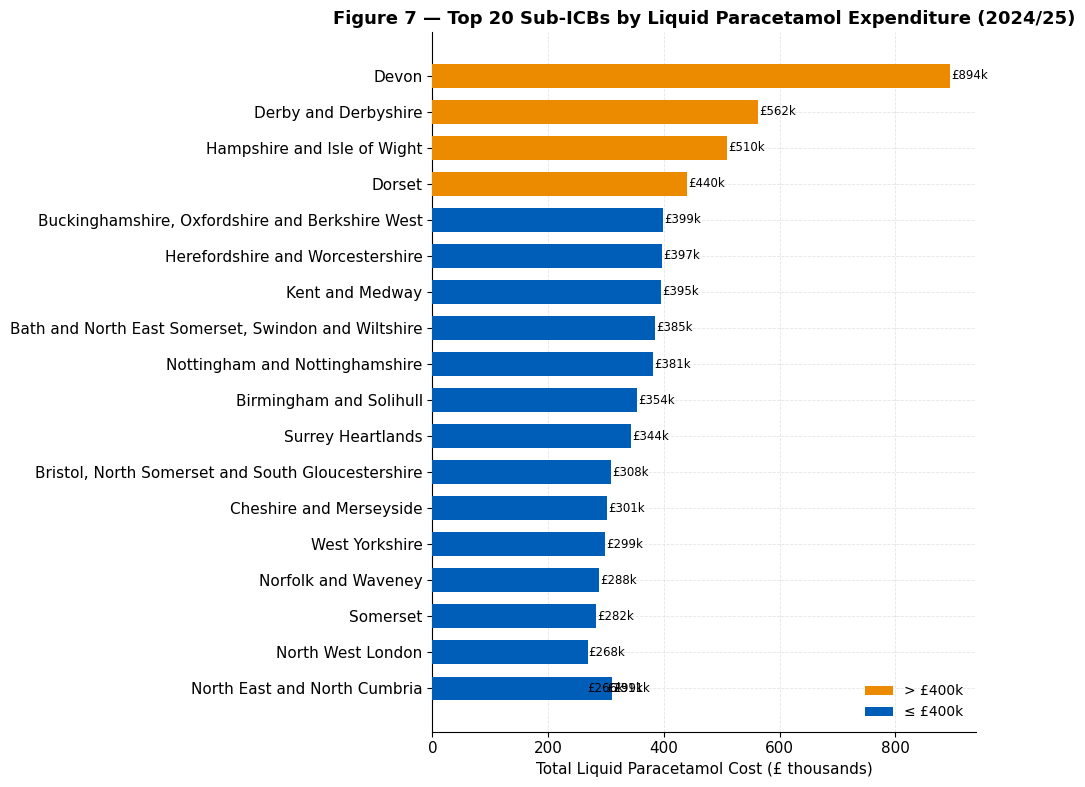

In [11]:
top20_cost = latest.nlargest(20, 'Cost').sort_values('Cost')

fig, ax = plt.subplots(figsize=(10, 8))
colours_bars = [NHS_ORANGE if c > 400000 else NHS_BLUE for c in top20_cost['Cost']]
bars = ax.barh(top20_cost['sub_short'], top20_cost['Cost'] / 1000,
               color=colours_bars, height=0.65, zorder=3)
for bar, v in zip(bars, top20_cost['Cost']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'£{v/1000:.0f}k', va='center', fontsize=8.5)

ax.set_xlabel('Total Liquid Paracetamol Cost (£ thousands)')
ax.set_title('Figure 7 — Top 20 Sub-ICBs by Liquid Paracetamol Expenditure (2024/25)', fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=NHS_ORANGE, label='> £400k'),
                   Patch(facecolor=NHS_BLUE,   label='≤ £400k')]
ax.legend(handles=legend_elements, frameon=False, fontsize=10)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig7_top20_absolute_spend.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:**

Devon has the highest absolute liquid paracetamol spend at around £894,000 in 2024/25, followed by Derby and Derbyshire at £562,000. Absolute spend is partly a function of Sub-ICB size and care home population, larger Sub-ICBs with more care home beds will naturally spend more in aggregate.

Notably, Greater Manchester which had the highest proportional liquid prescribing rate does not appear at the very top of the absolute cost chart. This illustrates why both metrics matter and why they tell different stories: a smaller Sub-ICB with a high proportion of liquid prescribing may spend less in total than a large Sub-ICB with a more moderate rate.

For budget planning, absolute cost is the relevant figure. For understanding prescribing patterns and potential population need, the proportional rate is more informative.


---
## 6. Relationship Between Liquid Prescribing Rate and Cost Share

We would expect Sub-ICBs with a higher proportion of liquid prescribing to also bear a higher share of total paracetamol costs, given the price premium of liquid formulations. This section examines that relationship.


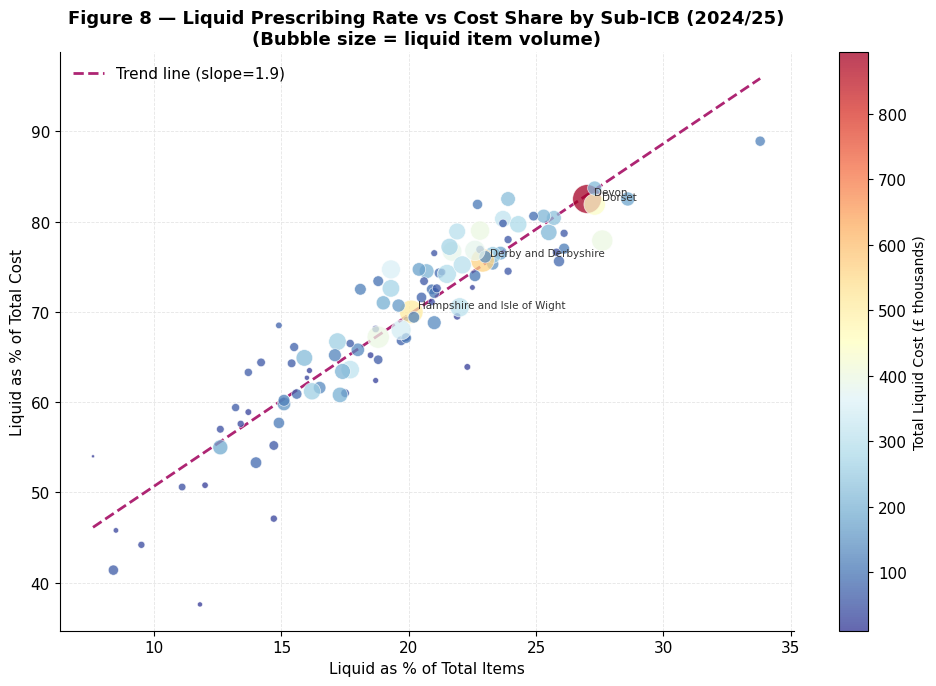

Pearson correlation between % items and % cost: r = 0.915


In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(latest['Percentage of items'], latest['Percentage of cost'],
                c=latest['Cost'] / 1000, cmap='RdYlBu_r',
                s=latest['Item count'] / 40, alpha=0.75, zorder=3, edgecolors='white', linewidth=0.5)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Total Liquid Cost (£ thousands)', fontsize=10)

m, b = np.polyfit(latest['Percentage of items'], latest['Percentage of cost'], 1)
x_line = np.linspace(latest['Percentage of items'].min(), latest['Percentage of items'].max(), 100)
ax.plot(x_line, m * x_line + b, color=NHS_PINK, linewidth=2, linestyle='--',
        label=f'Trend line (slope={m:.1f})')

for _, row in latest.nlargest(4, 'Cost').iterrows():
    ax.annotate(row['sub_short'], (row['Percentage of items'], row['Percentage of cost']),
                fontsize=7.5, xytext=(5, 3), textcoords='offset points', color='#333')

ax.set_xlabel('Liquid as % of Total Items')
ax.set_ylabel('Liquid as % of Total Cost')
ax.set_title('Figure 8 — Liquid Prescribing Rate vs Cost Share by Sub-ICB (2024/25)\n(Bubble size = liquid item volume)',
             fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig8_scatter_rate_vs_cost.png', dpi=150, bbox_inches='tight')
plt.show()

corr = latest['Percentage of items'].corr(latest['Percentage of cost'])
print(f"Pearson correlation between % items and % cost: r = {corr:.3f}")


**What this shows:**

There is a **strong positive correlation** (r ≈ 0.915) between the proportion of paracetamol items that are liquid and the proportion of total paracetamol cost attributable to liquid formulations. This is expected and reflects the price premium of liquid over tablet formulations.

The steep slope of the trend line confirms that even a modest increase in the proportion of liquid prescribing translates to a **disproportionately large** increase in cost share suggesting a direct consequence of the unit price differential explored in Section 3.2.

This relationship is largely structural: it describes the mathematics of pricing, not a behavioural signal. Sub-ICBs with more patients who clinically require liquid paracetamol will, by necessity, sit further along both axes.



---
## 7. Cost Changes Across Sub-ICBs Over Time

This section examines how liquid paracetamol costs have changed at Sub-ICB level between 2020/21 and 2024/25, focusing on the **top 20 Sub-ICBs by absolute cost increase**. Since national unit prices have risen substantially over this period, we would expect virtually every Sub-ICB to show cost increases. The more informative question is whether some areas have grown significantly faster or slower than the national average (+240%), and what might explain those differences.

We look at both **absolute cost increase** (how much more in pounds) and **percentage cost increase** (how much more relative to their starting point), as each tells a different story. We also bring in item volume and patient count changes to help distinguish price-driven increases from population-driven ones.


National average cost increase 2020/21 → 2024/25: +239.6%


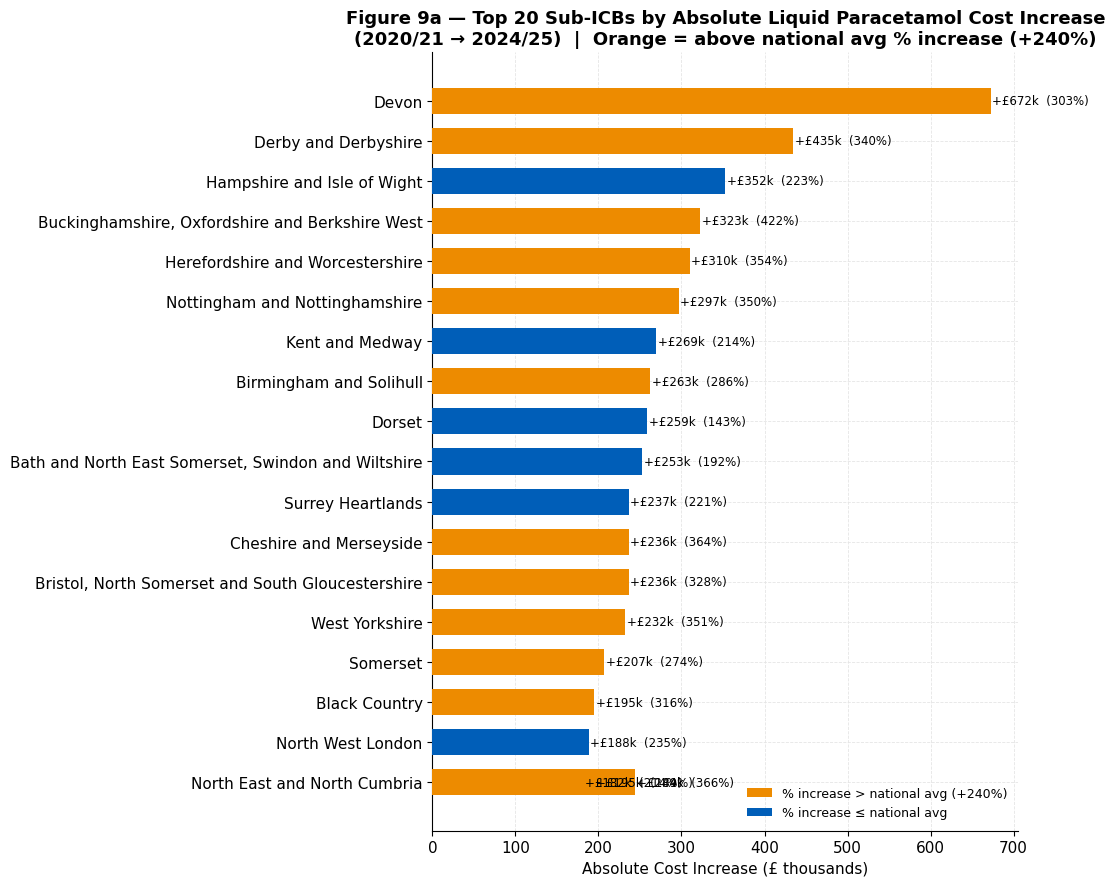

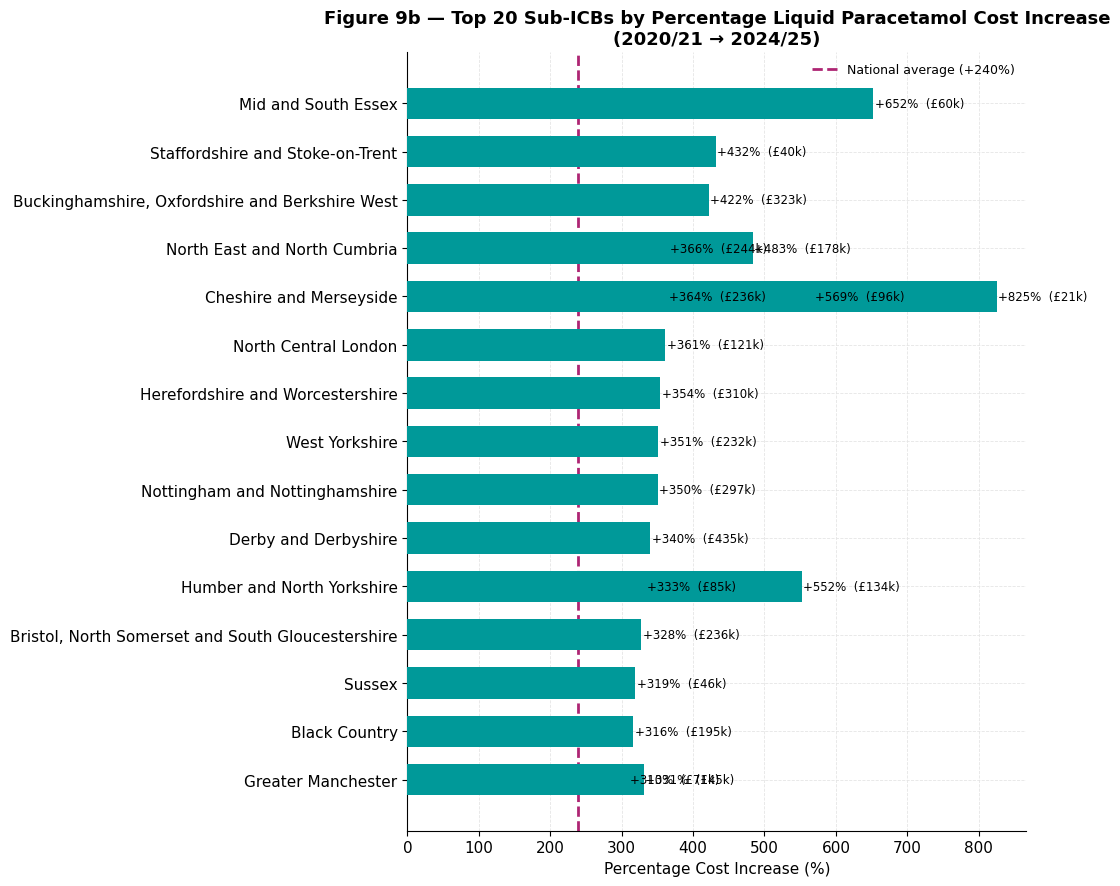

In [13]:
cost_2021 = liquid[liquid['Financial year'] == '2020/21'][['Sub ICB','Cost','Item count','Patient count']].rename(
    columns={'Cost':'cost_2021','Item count':'items_2021','Patient count':'patients_2021'})
cost_2425 = liquid[liquid['Financial year'] == '2024/25'][['Sub ICB','Cost','Item count','Patient count']].rename(
    columns={'Cost':'cost_2425','Item count':'items_2425','Patient count':'patients_2425'})

change = cost_2021.merge(cost_2425, on='Sub ICB')
change['abs_change']          = change['cost_2425'] - change['cost_2021']
change['pct_change']          = (change['abs_change'] / change['cost_2021']) * 100
change['item_change_pct']     = (change['items_2425'] - change['items_2021']) / change['items_2021'] * 100
change['patient_change_pct']  = (change['patients_2425'] - change['patients_2021']) / change['patients_2021'] * 100
change['cost_per_item_2021']  = change['cost_2021'] / change['items_2021']
change['cost_per_item_2425']  = change['cost_2425'] / change['items_2425']
change['sub_short']           = change['Sub ICB'].str.split(' - ').str[0]

nat_2021    = liquid[liquid['Financial year'] == '2020/21']['Cost'].sum()
nat_2425    = liquid[liquid['Financial year'] == '2024/25']['Cost'].sum()
nat_pct_change = (nat_2425 - nat_2021) / nat_2021 * 100
print(f"National average cost increase 2020/21 → 2024/25: +{nat_pct_change:.1f}%")

top20_abs = change.nlargest(20, 'abs_change').sort_values('abs_change')
top20_pct = change.nlargest(20, 'pct_change').sort_values('pct_change')

# ── Figure 9a: Top 20 by absolute cost increase ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
colours_abs = [NHS_ORANGE if v > nat_pct_change else NHS_BLUE
               for v in top20_abs['pct_change']]
bars = ax.barh(top20_abs['sub_short'], top20_abs['abs_change'] / 1000,
               color=colours_abs, height=0.65, zorder=3)
for bar, row in zip(bars, top20_abs.itertuples()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'+£{row.abs_change/1000:.0f}k  ({row.pct_change:.0f}%)',
            va='center', fontsize=8.5)
ax.set_xlabel('Absolute Cost Increase (£ thousands)')
ax.set_title('Figure 9a — Top 20 Sub-ICBs by Absolute Liquid Paracetamol Cost Increase\n'
             '(2020/21 → 2024/25)  |  Orange = above national avg % increase (+240%)',
             fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=NHS_ORANGE, label=f'% increase > national avg (+{nat_pct_change:.0f}%)'),
                   Patch(facecolor=NHS_BLUE,   label=f'% increase ≤ national avg')]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig9a_top20_absolute_increase.png', dpi=150, bbox_inches='tight')
plt.savefig('images/fig9b_top20_pct_increase.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 9b: Top 20 by percentage cost increase ────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
bars2 = ax.barh(top20_pct['sub_short'], top20_pct['pct_change'],
                color=NHS_TEAL, height=0.65, zorder=3)
for bar, row in zip(bars2, top20_pct.itertuples()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'+{row.pct_change:.0f}%  (£{row.abs_change/1000:.0f}k)',
            va='center', fontsize=8.5)
ax.axvline(nat_pct_change, color=NHS_PINK, linewidth=2, linestyle='--',
           label=f'National average (+{nat_pct_change:.0f}%)')
ax.set_xlabel('Percentage Cost Increase (%)')
ax.set_title('Figure 9b — Top 20 Sub-ICBs by Percentage Liquid Paracetamol Cost Increase\n'
             '(2020/21 → 2024/25)',
             fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**What this shows:**

The national average cost increase between 2020/21 and 2024/25 is **+240%**. This is the baseline against which every Sub-ICB should be read — any Sub-ICB tracking close to this figure has seen cost increases driven almost entirely by the national unit price rise, with broadly stable prescribing behaviour. Sub-ICBs significantly above it have seen both price increases *and* meaningful growth in liquid prescribing volume or patient numbers.

**Figure 9a — Absolute cost increase (top 20):**

The bars are coloured to distinguish Sub-ICBs whose percentage increase was above (orange) or below (blue) the national average, helping to separate large-but-expected increases from genuinely outsized ones.

- **Devon (+£672k, +303%)** has the largest absolute cost increase and sits above the national average in percentage terms. Its item volume grew by 37% and patient count by 26% — both meaningful increases on top of the price effect. Devon is both a large Sub-ICB and one where the care home population appears to have grown, making it the highest-cost area by some margin.

- **Derby and Derbyshire (+£435k, +340%)** shows above-average percentage growth alongside a 50% increase in items and a 32% increase in patients. This combination of volume and price growth places it clearly above the national average.

- **Buckinghamshire, Oxfordshire and Berkshire West (+£323k, +422%)** has the highest percentage increase among the top 20 by absolute cost, at more than 4x the 2020/21 figure. Items grew by 75% and patient count by 45% — the strongest volume growth in the top 20. This suggests a substantial expansion of the liquid-prescribing patient population, not just a price effect.

- **Herefordshire and Worcestershire (+£310k, +354%)** and **Nottingham and Nottinghamshire (+£297k, +350%)** both show above-national-average percentage increases, with item growth of 65% and 88% respectively. These are notable — particularly Nottinghamshire where items nearly doubled. This warrants local investigation, though again it may reflect genuine population growth in care home capacity.

- **Hampshire and Isle of Wight (+£352k, +224%)** and **Kent and Medway (+£269k, +214%)** both sit *below* the national average in percentage terms despite large absolute increases. Their cost growth is primarily explained by the price rise — their item volumes grew modestly (24% and 25%) and patient counts grew by 14–18%. These are large Sub-ICBs whose costs increased in proportion to the national trend.

- **Bath and North East Somerset, Swindon and Wiltshire (+£253k, +192%)** is the only Sub-ICB in the top 20 that sits notably *below* the national average, with item growth of just 13% and patient growth of only 3%. This suggests its liquid prescribing volume has been largely stable — its cost increase is almost entirely price-driven, not volume-driven.

- **Somerset (+£207k, +274%)** similarly shows very low patient growth (3%) but a 29% item growth and above-national-average percentage cost increase, which could reflect more items per patient rather than new patients — worth exploring locally.

- **North East and North Cumbria** appears three times in the top 20 (codes 00P, 16C, 84H) as separate Sub-ICB units within the same broader geography. Collectively they represent a significant share of the top 20 total. Their individual percentage increases range from 189% to 366%.


**Figure 9b — Percentage cost increase (top 20):**

This chart removes the size effect — a Sub-ICB with a small base can show a very large percentage increase even with a modest absolute change. The top performers here are:

- **Nottingham and Nottinghamshire (+350%)**, **Cheshire and Merseyside (+364%)**, and **North East and North Cumbria - 00P (+366%)** all show the steepest proportional growth, driven by a combination of item volume increases of 45–88% on top of the universal price rise.

- Sub-ICBs near or just above the national average line (+240%) are essentially tracking the price increase with modest volume growth — their prescribing behaviour has not changed dramatically.



**Overall interpretation:**

The majority of cost growth across all Sub-ICBs is attributable to the national unit price increase. However, a subset of Sub-ICBs — particularly Buckinghamshire/Oxfordshire/Berkshire West, Nottinghamshire, Derby and Derbyshire, and Cheshire and Merseyside — show volume and patient growth well above the national trend. This could reflect genuine expansion of the care home population or patients with liquid-paracetamol-appropriate clinical needs. As with the prescribing rate analysis in Section 5, these areas warrant local contextual investigation rather than assumptions about prescribing appropriateness.


---
## 8. Year-on-Year Trends for the Ten Highest-Cost Sub-ICBs


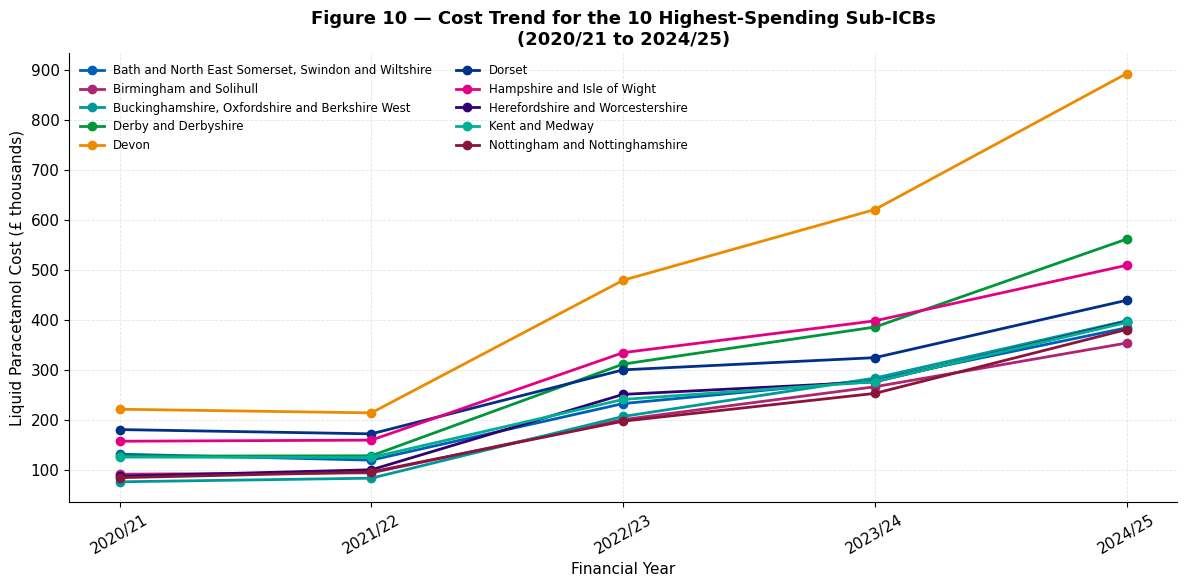

In [14]:
top10_areas = latest.nlargest(10, 'Cost')['Sub ICB'].tolist()
top10_data  = liquid[liquid['Sub ICB'].isin(top10_areas)].copy()
top10_data['sub_short'] = top10_data['Sub ICB'].str.split(' - ').str[0]

fig, ax = plt.subplots(figsize=(12, 6))
palette = [NHS_BLUE, NHS_PINK, NHS_TEAL, NHS_GREEN, NHS_ORANGE,
           NHS_DARK, '#E40085', '#330072', '#00B092', '#8A1538']

for i, (area, grp) in enumerate(top10_data.groupby('sub_short')):
    grp_sorted = grp.sort_values('Financial year')
    ax.plot(grp_sorted['Financial year'], grp_sorted['Cost'] / 1000,
            marker='o', linewidth=2, markersize=6,
            color=palette[i % len(palette)], label=area, zorder=3)

ax.set_ylabel('Liquid Paracetamol Cost (£ thousands)')
ax.set_xlabel('Financial Year')
ax.set_title('Figure 10 — Cost Trend for the 10 Highest-Spending Sub-ICBs\n(2020/21 to 2024/25)',
             fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper left', frameon=False, fontsize=8.5, ncol=2)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/fig10_top10_trends.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:**

All ten of the highest-spending Sub-ICBs show a broadly similar upward cost trajectory, consistent with the national unit price increases. The inflection point around 2021/22–2022/23 when the cost per item nearly doubled is visible in most lines as a steepening of the curve.

Devon has maintained the highest costs throughout the period. Some Sub-ICBs (Hampshire and Isle of Wight, Buckinghamshire, Oxfordshire and Berkshire West) show steeper recent rises, which may reflect both price increases and growth in their care home patient population.

The parallel nature of these curves reinforces that **price** is the dominant driver across all areas, individual Sub-ICB trajectories reflect local population growth layered on top of a national price effect.



## 9. Summary of Key Findings

| Finding | Detail |
|---|---|
| **Prescribing volume has grown moderately** | Liquid paracetamol items grew from ~272,000 to ~371,000 (+37%) — broadly consistent with care home population growth |
| **Costs have risen far faster than volume** | Total cost increased from £4.7M to £16.1M (+240%) |
| **Unit price is the primary driver** | Cost per item rose from £17.40 to £43.26 (+149%); the sharpest increase occurred in 2021/22–2022/23 |
| **Patient numbers have grown steadily** | The number of patients receiving liquid paracetamol grew 22%, suggesting a growing clinical need, not a sudden change in prescribing behaviour |
| **Liquid's cost share has grown due to price, not volume** | Liquid items are ~20% of all paracetamol items — stable over five years — but now account for >71% of total paracetamol cost |
| **Geographic variation exists but context is limited** | Liquid prescribing rates range from 7.6% to 33.8% across Sub-ICBs; the causes require local investigation |

## 10. Interpretation and Limitations

**What this analysis can say:**
- Liquid paracetamol costs have risen substantially and the trend is continuing
- The increase is predominantly a supply-side pricing phenomenon, not a prescribing behaviour change
- Geographic variation in liquid prescribing rates exists and is worth monitoring
- Some Sub-ICBs have grown faster than the national average in percentage terms and may benefit from local review

**What this analysis cannot say:**
- Whether any specific Sub-ICB is over- or under-prescribing liquid paracetamol
- Whether the patients receiving liquid formulations are clinically appropriate recipients (this requires patient-level data)
- Whether variation reflects genuine differences in clinical practice or simply differences in population characteristics
- Whether cost increases could be mitigated through procurement changes (this requires contract-level data)

**Recommended next steps for commissioners:**
- Cross-reference liquid prescribing rates with local care home bed capacity and dysphagia referral data
- Engage with Sub-ICBs at the extreme ends of the distribution to understand local context before drawing conclusions
- Monitor price trends through NHSBSA and consider national procurement levers to address unit cost pressures
- Avoid using this dataset alone as the basis for prescribing improvement targets


---
## Appendix: Full Sub-ICB Table (2024/25)


In [15]:
full_table = latest[['Sub ICB','Item count','Cost','Patient count',
                      'Percentage of items','Percentage of cost','Percentage of patients']].copy()
full_table = full_table.sort_values('Cost', ascending=False).reset_index(drop=True)
full_table.columns = ['Sub-ICB','Items','Cost (£)','Patients',
                      '% Items (Liquid)','% Cost (Liquid)','% Patients (Liquid)']
full_table.style.format({
    'Items':                   '{:,.0f}',
    'Cost (£)':                '£{:,.0f}',
    'Patients':                '{:,.0f}',
    '% Items (Liquid)':        '{:.1f}%',
    '% Cost (Liquid)':         '{:.1f}%',
    '% Patients (Liquid)':     '{:.1f}%',
}).background_gradient(subset=['Cost (£)'], cmap='Blues')


,Sub-ICB,Items,Cost (£),Patients,% Items (Liquid),% Cost (Liquid),% Patients (Liquid)
0,Devon - 15N,"17,060","£893,830","3,400",27.0%,82.5%,30.8%
1,Derby and Derbyshire - 15M,"11,310","£562,360","2,380",22.9%,75.7%,27.1%
2,Hampshire and Isle of Wight - D9Y0V,"11,430","£509,900","2,860",20.1%,70.0%,24.5%
3,Dorset - 11J,"9,560","£439,860","2,200",27.3%,81.9%,32.9%
4,"Buckinghamshire, Oxfordshire and Berkshire West - 10Q","7,630","£398,880","1,390",22.8%,79.0%,27.0%
5,Herefordshire and Worcestershire - 18C,"9,210","£397,120","2,050",27.6%,77.9%,32.5%
6,Kent and Medway - 91Q,"10,170","£395,420","2,680",18.8%,67.2%,22.7%
7,"Bath and North East Somerset, Swindon and Wiltshire - 92G","7,920","£384,760","1,580",21.7%,76.7%,25.2%
8,Nottingham and Nottinghamshire - 52R,"8,540","£381,340","1,760",22.6%,76.8%,26.1%
9,Birmingham and Solihull - 15E,"7,410","£354,220","1,590",19.3%,74.7%,23.4%
